In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

session_wide_optimal_lags = []
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
for mouse, days in mouse_days.items():
    for day in days:

        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day)
        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
        if len(all) > 0:
            session_travel_lag = all['session_travel_lag'].iloc[0]
            session_wide_optimal_lags.append(session_travel_lag)


20 14
optimal travel lag is 0.2502502502502537 cm
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
20 15
optimal travel lag is 3.753753753753756 cm
there are 61 non_grid and non_spatial_cells
there are 1 grid_cells
there are 50 non grid spatial cells
there are 11 non spatial cells
there are 11 speed cells
there are 73 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
for the grid cells the unique locations are ['ENTm3']
20 16
optimal travel lag is 10.860860860860868 cm
there are 178 non_grid and non_spatial_cells
there are 3 grid_cells
there are 156 non grid spatial cells
there are 22 non spatial cells
there are 38 speed cells
there are 219 cells
for the non-grid spatial cells the unique locations are ['ENTm3']
for the grid cells t

In [3]:
print(f"Total number of GC cells: {len(gcs_)}")
print(f"Total number of NGS cells: {len(ngs_)}")
print(f'Total number of reference cells: {len(gcs_) + len(ngs_)}')

Total number of GC cells: 517
Total number of NGS cells: 5413
Total number of reference cells: 5930


every NGS, and GC cell will be used as a reference cell

it can either have a training set with NGS cells, cmGC or ncmGC
it can either have the ordering mode as nearest, farthest or random


I need to write a script that will submit all the jobs, and keep track of which jobs have been submitted 

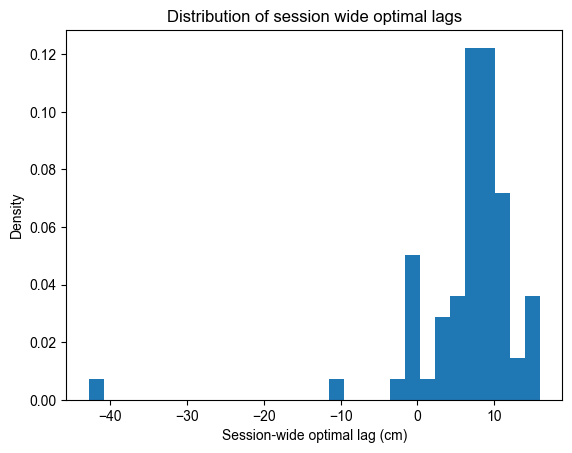

In [4]:
plt.hist(session_wide_optimal_lags, bins=30, density=True)
plt.xlabel('Session-wide optimal lag (cm)')
plt.ylabel('Density')
plt.title('Distribution of session wide optimal lags')
plt.show()